Multiple Sequence Alignment
1. MultipleSeqAlignment
2. Sequence alignment 결과 파일 읽고 파싱하고 서열 중간을 슬라이싱, 서열 정렬 진행
3. 보존 서열을 알 수 있는 Weblogo를 그리고 종 간 유사도를 알아볼 수 있는 계통수 그리기

AlignIO.read() method에는
1. 파일 / 파일을 연 객체
2. 파일 종류
를 삽입한다

파일 ex : ClustalW, clustal, emboss, stockholm...


In [2]:
#7.2.read_MSA_example.py

from Bio import AlignIO
alignment = AlignIO.read("example.aln","clustal")
print(alignment)

Alignment with 3 rows and 142 columns
MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYF...KYR sp|P69905|HBA_HUMAN
MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYF...KYR sp|P69907|HBA_PANTR
MVLSGEDKSNIKAAWGKIGGHGAEYGAEALERMFASFPTTKTYF...KYR sp|P01942|HBA_MOUSE


In [ ]:
#MSA 객체에서 서열/ID 부분을 분리하는 방법

#7.3.read_MSA_example_1.py

from Bio import AlignIO
alignment = AlignIO.read("example.aln","clustal")

for record in alignment:
    print("%s\n%s" % (record.seq, record.id))

#각 행의 SeqRecord 객체에서 seq, id 속성을 가져옴

MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR
sp|P69905|HBA_HUMAN
MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR
sp|P69907|HBA_PANTR
MVLSGEDKSNIKAAWGKIGGHGAEYGAEALERMFASFPTTKTYFPHFDVSHGSAQVKGHGKKVADALASAAGHLDDLPGALSALSDLHAHKLRVDPVNFKLLSHCLLVTLASHHPADFTPAVHASLDKFLASVSTVLTSKYR
sp|P01942|HBA_MOUSE


In [6]:
#각 SeqRecord 객체의 서열에서 앞 10개 서열을 가져오는 법

#7.3.read_MSA_example_2.py

from Bio import AlignIO

alignment = AlignIO.read("example.aln","clustal")
for record in alignment:
    print("%s\n%s" %(record.seq[:10],record.id))

MVLSPADKTN
sp|P69905|HBA_HUMAN
MVLSPADKTN
sp|P69907|HBA_PANTR
MVLSGEDKSN
sp|P01942|HBA_MOUSE


In [ ]:
#7.4.3.muslce_cmd_example.py

import subprocess

muscle_exe = "/Users/jangsehwan/TEST1/생물정보학 바이오파이썬/MUSCLE/muscle3.8.31_i86darwin64"

cmd_line = [muscle_exe, "-in", "HBA.all.fasta", "-out", "HBA.aln", "-clw"]

print(cmd_line)

result = subprocess.run(cmd_line, capture_output=True, text=True)
stdout = result.stdout
stderr = result.stderr
#실행 시 HBA.aln 파일이 생성됨

['/Users/jangsehwan/TEST1/생물정보학 바이오파이썬/MUSCLE/muscle3.8.31_i86darwin64', '-in', 'HBA.all.fasta', '-out', 'HBA.aln', '-clw']


Weblogo 작성 홈페이지 :
http://weblogo.threeplusone.com

In [22]:
#BioPython으로 Weblogo 그리기
# 1. motifs.create()로 Motif 객체 생성
# 2. Motif.weblogo()로 Weblogo 생성

#7.5.2.WebLogo_example_1.py

from Bio.motifs import Motif
from Bio import motifs
from Bio.Seq import Seq

instances = [Seq("TACAA"),
             Seq("TACGC"),
             Seq("TACAC"),
             Seq("TACCC"),
             Seq("AACCC"),
             Seq("AATGC"),
             Seq("AATGC")]

m = motifs.create(instances)

print(m.counts)
Motif.weblogo(m,'test.png')


        0      1      2      3      4
A:   3.00   7.00   0.00   2.00   1.00
C:   0.00   0.00   5.00   2.00   6.00
G:   0.00   0.00   0.00   3.00   0.00
T:   4.00   0.00   2.00   0.00   0.00



In [ ]:
#Jupyter Notebook에서 생성하는 법

from IPython.display import Image
Image("test2.png")

In [ ]:
# MSA 결과 파일로부터 WebLogo 그리는 법


from Bio import AlignIO
from Bio.motifs import Motif
from Bio import motifs
from Bio.Seq import Seq

alignment = AlignIO.read("HBA.aln", "clustal")
instance = []

for record in alignment:
    s = Seq(str(record.seq))
    instance.append(s)

m = motifs.create(instance, alphabet="ACDEFGHIKLMNPQRSTVWY")
Motif.weblogo(m, "HBA_WebLogo_2.png", fmt="png")

Tree(rooted=False, weight=1.0)
    Clade()
        Clade(branch_length=0.00537)
            Clade(branch_length=0.29387, name='sp|P01994|HBA_CHICK')
            Clade(branch_length=0.01203)
                Clade(branch_length=0.01282)
                    Clade(branch_length=0.1181, name='sp|P60529|HBA_CANLF')
                    Clade(branch_length=0.10357, name='sp|P01948|HBA_RABIT')
                Clade(branch_length=0.00617)
                    Clade(branch_length=0.05673)
                        Clade(branch_length=0.0, name='sp|P69907|HBA_PANTR')
                        Clade(branch_length=0.0, name='sp|P69905|HBA_HUMAN')
                    Clade(branch_length=0.07405, name='sp|P01958|HBA_HORSE')
        Clade(branch_length=0.13313, name='sp|P18971|HBA_BALAC')
        Clade(branch_length=0.06808, name='sp|P01942|HBA_MOUSE')


Matplotlib is building the font cache; this may take a moment.


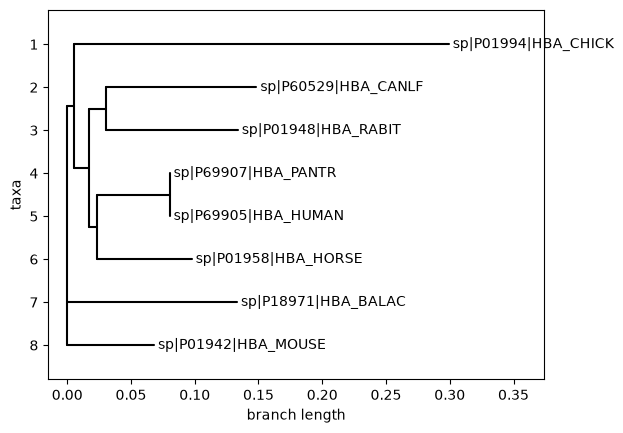

In [29]:
# 계통수 그리기
# 7.6.phylo_example.py

from Bio import Phylo

tree = Phylo.read('HBA.newick','newick')
print(tree)

Phylo.draw(tree)

Tree(rooted=False, weight=1.0)
    Clade(name='Homo_ott770309')
        Clade()
            Clade()
                Clade()
                    Clade()
                        Clade(name='Homo_sapiens_ott770315')
                            Clade(name='Homo_sapiens_neanderthalensis_ott83926')
                            Clade(name='Homo_sapiens_sapiens_ott5341349')
                        Clade(name='Homo_heidelbergensis_ott3607676')
                    Clade(name='Homo_antecessor_ott3607681')
                Clade(name='Homo_erectus_ott3607671')
            Clade(name='Homo_habilis_ott3607678')
        Clade(name='Homo_rudolfensis_ott3607673')


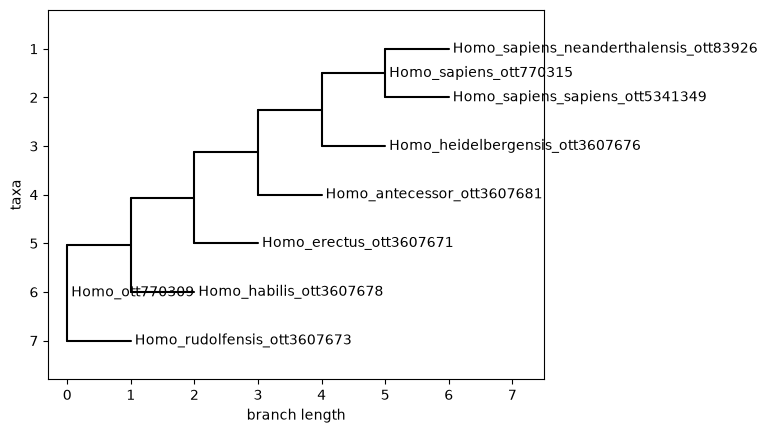

In [32]:
# 계통수 그리기
# 7.6.phylo_example.py

from Bio import Phylo

tree = Phylo.read('homo.tre','newick')
print(tree)

Phylo.draw(tree)